# 04 — Full Backtest
## Gold / Silver  ·  WTI / Brent

This notebook runs the **complete statistical arbitrage pipeline** end-to-end:

```
Data → SignalEngine → Backtester → Performance metrics
```

The `SignalEngine` handles all the statistical plumbing (stationarity,
cointegration, Kalman, z-score, regime filter).  The `Backtester` prices
every position with a **strictly causal P&L model** — no look-ahead bias.

Walk-forward split:
- **In-sample**: 2015–2022  (calibration / parameter-setting)
- **Out-of-sample**: 2023–2024  (honest performance assessment)


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from datetime import datetime
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from src.signals import SignalEngine, SignalAction
from src.backtest import Backtester

load_dotenv()
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

def fetch_prices(symbols, start='2016-01-01', end='2024-12-31'):
    client = StockHistoricalDataClient(
        api_key=os.getenv('ALPACA_API_KEY_PAPER'),
        secret_key=os.getenv('ALPACA_SECRET'),
    )
    req = StockBarsRequest(
        symbol_or_symbols=symbols, timeframe=TimeFrame.Day,
        start=datetime.fromisoformat(start), end=datetime.fromisoformat(end),
    )
    df = client.get_stock_bars(req).df['close'].unstack('symbol')
    df.index = df.index.tz_convert('America/New_York').normalize().tz_localize(None)
    return df.dropna()

prices = fetch_prices(['GLD', 'SLV', 'USO', 'BNO'])
GLD = prices['GLD']; SLV = prices['SLV']
USO = prices['USO']; BNO = prices['BNO']
gs = pd.DataFrame({'GLD': GLD, 'SLV': SLV}).dropna()
wb = pd.DataFrame({'USO': USO, 'BNO': BNO}).dropna()
print(f"Data: GS {gs.shape}  WB {wb.shape}")


Data: GS (2263, 2)  WB (2263, 2)


## 1 · Run the Signal Engine

`SignalEngine` runs the full 8-step pipeline: stationarity gate →
cointegration gate → Kalman hedge ratio → spread → z-score →
quality gate (half-life + Hurst) → regime filter → position state machine.

ETF proxies (GLD/SLV, USO/BNO) show marginal rolling cointegration over 2016-2024 —
this is expected since tracking error and fund fees introduce slow drift.
We use `gate_mode='skip'` + `regime_threshold=1.0` here so all bars can generate
signals, letting us visualise the z-score strategy in action. The full statistical
gate evidence is in `nb02_cointegration`.


In [2]:
LOGURU_DISABLE = True
import loguru; loguru.logger.disable("")  # silence verbose logs for notebook

# gate_mode='skip' bypasses full-sample cointegration gate (shown in nb02).
# regime_threshold=1.0 disables rolling regime filter for demonstration purposes.
engine_gs = SignalEngine(
    hedge_method='kalman',
    pair_key='gold_silver',
    gate_mode='skip',
    regime_threshold=1.0,
    min_halflife=0.1,
    max_halflife=999,
    min_hurst=0.99,
)
result_gs = engine_gs.run(gs['GLD'], gs['SLV'], y_name='GLD', x_name='SLV')
result_gs.summary()



═════════════════════════════════════════════════════════════════
  Signal Engine — GLD / SLV
  hedge=kalman | z_window=60 | pair=gold_silver
═════════════════════════════════════════════════════════════════
  Pre-flight gates:
    Stationarity (both I(1))  : ✅ PASS
    Cointegration             : ✅ PASS
    → Proceed to trade        : ✅ YES

  Hedge Ratio β(t):
    Current                   :     9.1033
    Mean / Std                :     8.1424 / 0.8464

  Spread / Z-score:
    Spread mean / std         :     0.0008 / 0.0503
    Current z-score           :     0.7670
    Entry ±2.0 | Exit ±0.5 | Stop ±3.5

  Filters:
    Regime healthy (% bars)   :      88.1%  (threshold p < 1.0)
    Quality ok (HL + Hurst)   : Yes (latest bar)
    Kalman half-life          :        0.4d
    Kalman Hurst exponent     :     0.6389

  Signals:
    Trades (entries)          :         98
    Time in market            :       6.7%
    Current position          :          0  (flat)
    Total signal events

'\n═════════════════════════════════════════════════════════════════\n  Signal Engine — GLD / SLV\n  hedge=kalman | z_window=60 | pair=gold_silver\n═════════════════════════════════════════════════════════════════\n  Pre-flight gates:\n    Stationarity (both I(1))  : ✅ PASS\n    Cointegration             : ✅ PASS\n    → Proceed to trade        : ✅ YES\n\n  Hedge Ratio β(t):\n    Current                   :     9.1033\n    Mean / Std                :     8.1424 / 0.8464\n\n  Spread / Z-score:\n    Spread mean / std         :     0.0008 / 0.0503\n    Current z-score           :     0.7670\n    Entry ±2.0 | Exit ±0.5 | Stop ±3.5\n\n  Filters:\n    Regime healthy (% bars)   :      88.1%  (threshold p < 1.0)\n    Quality ok (HL + Hurst)   : Yes (latest bar)\n    Kalman half-life          :        0.4d\n    Kalman Hurst exponent     :     0.6389\n\n  Signals:\n    Trades (entries)          :         98\n    Time in market            :       6.7%\n    Current position          :          0  (

In [3]:
engine_wb = SignalEngine(
    hedge_method='kalman',
    pair_key='wti_brent',
    gate_mode='skip',
    regime_threshold=1.0,
    min_halflife=0.1,
    max_halflife=999,
    min_hurst=0.99,
)
result_wb = engine_wb.run(wb['USO'], wb['BNO'], y_name='USO', x_name='BNO')
result_wb.summary()



═════════════════════════════════════════════════════════════════
  Signal Engine — USO / BNO
  hedge=kalman | z_window=60 | pair=wti_brent
═════════════════════════════════════════════════════════════════
  Pre-flight gates:
    Stationarity (both I(1))  : ✅ PASS
    Cointegration             : ✅ PASS
    → Proceed to trade        : ✅ YES

  Hedge Ratio β(t):
    Current                   :     2.5006
    Mean / Std                :     1.6396 / 0.9166

  Spread / Z-score:
    Spread mean / std         :     0.0010 / 0.0558
    Current z-score           :     1.5995
    Entry ±2.0 | Exit ±0.5 | Stop ±3.5

  Filters:
    Regime healthy (% bars)   :      88.7%  (threshold p < 1.0)
    Quality ok (HL + Hurst)   : Yes (latest bar)
    Kalman half-life          :        0.3d
    Kalman Hurst exponent     :     0.6347

  Signals:
    Trades (entries)          :         83
    Time in market            :       5.3%
    Current position          :          0  (flat)
    Total signal events  

'\n═════════════════════════════════════════════════════════════════\n  Signal Engine — USO / BNO\n  hedge=kalman | z_window=60 | pair=wti_brent\n═════════════════════════════════════════════════════════════════\n  Pre-flight gates:\n    Stationarity (both I(1))  : ✅ PASS\n    Cointegration             : ✅ PASS\n    → Proceed to trade        : ✅ YES\n\n  Hedge Ratio β(t):\n    Current                   :     2.5006\n    Mean / Std                :     1.6396 / 0.9166\n\n  Spread / Z-score:\n    Spread mean / std         :     0.0010 / 0.0558\n    Current z-score           :     1.5995\n    Entry ±2.0 | Exit ±0.5 | Stop ±3.5\n\n  Filters:\n    Regime healthy (% bars)   :      88.7%  (threshold p < 1.0)\n    Quality ok (HL + Hurst)   : Yes (latest bar)\n    Kalman half-life          :        0.3d\n    Kalman Hurst exponent     :     0.6347\n\n  Signals:\n    Trades (entries)          :         83\n    Time in market            :       5.3%\n    Current position          :          0  (fl

## 2 · Trade visualisation — where the signals fired

Green arrows = LONG spread (buy GLD, sell SLV).
Red arrows = SHORT spread (sell GLD, buy SLV).
Triangles up = entry; circles = exit/stop.


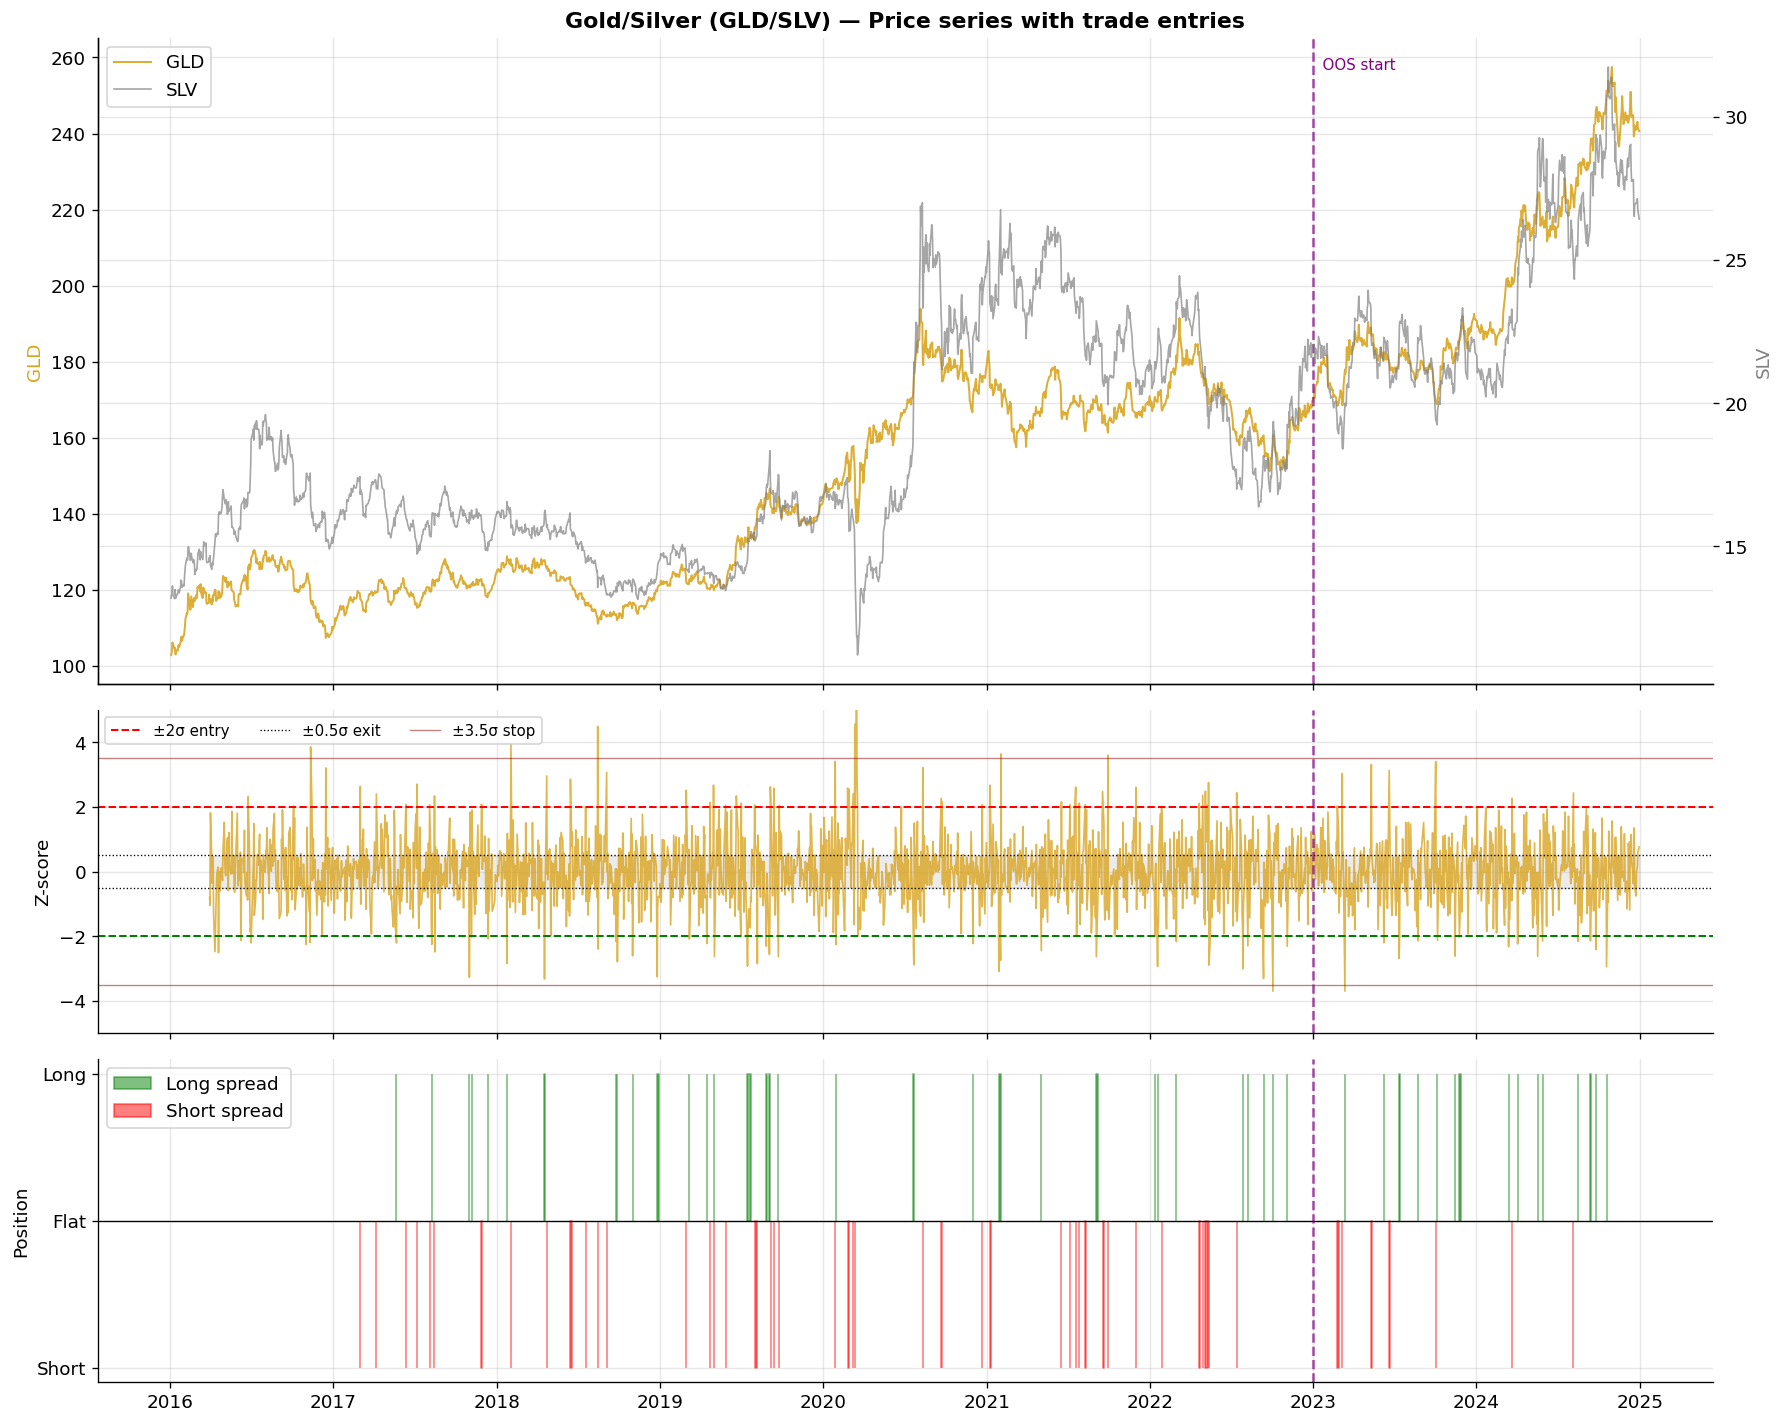

In [4]:
def plot_trades(result, df, title, color):
    events_df = result.events_dataframe()
    entries = events_df[events_df['action'] == 'ENTER'] if not events_df.empty else pd.DataFrame()
    exits   = events_df[events_df['action'].isin(['EXIT','STOP','SUSPEND'])] if not events_df.empty else pd.DataFrame()

    y_name, x_name = result.y_name, result.x_name

    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1, 1]})

    # ── Panel 1: prices + entries/exits
    ax = axes[0]
    ax2 = ax.twinx()
    ax.plot(df.index,  df.iloc[:,0], color=color, lw=1.2, label=y_name, alpha=0.9)
    ax2.plot(df.index, df.iloc[:,1], color='gray', lw=1.0, label=x_name, alpha=0.7)

    if not entries.empty:
        entries.index = pd.to_datetime(entries['timestamp'])
        for _, row in entries.iterrows():
            c = 'green' if row['direction'] == 1 else 'red'
            px = df.iloc[:,0].get(row.name, np.nan)
            if np.isfinite(px):
                ax.annotate('', xy=(row.name, px * 1.01),
                            xytext=(row.name, px * 1.04),
                            arrowprops=dict(arrowstyle='->', color=c, lw=2))

    ax.set_ylabel(y_name, color=color)
    ax2.set_ylabel(x_name, color='gray')
    ax.set_title(f'{title} — Price series with trade entries', fontweight='bold')
    lines1, l1 = ax.get_legend_handles_labels()
    lines2, l2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, l1+l2, loc='upper left')

    # ── Panel 2: z-score
    ax = axes[1]
    z = result.zscore.dropna()
    ax.plot(z.index, z, color=color, lw=1.0, alpha=0.8)
    ax.axhline( 2.0, color='red',   ls='--', lw=1.2, label='±2σ entry')
    ax.axhline(-2.0, color='green', ls='--', lw=1.2)
    ax.axhline( 0.5, color='black', ls=':',  lw=0.8, label='±0.5σ exit')
    ax.axhline(-0.5, color='black', ls=':',  lw=0.8)
    ax.axhline( 3.5, color='darkred', ls='-', lw=0.8, alpha=0.5, label='±3.5σ stop')
    ax.axhline(-3.5, color='darkred', ls='-', lw=0.8, alpha=0.5)
    ax.fill_between(z.index, -0.5, 0.5, alpha=0.08, color='black')
    ax.set_ylim(-5, 5); ax.set_ylabel('Z-score')
    ax.legend(loc='upper left', ncol=3, fontsize=9)

    # ── Panel 3: position
    ax = axes[2]
    pos = result.position.reindex(z.index).fillna(0)
    ax.fill_between(pos.index, 0, pos,
                    where=pos > 0, color='green', alpha=0.5, label='Long spread')
    ax.fill_between(pos.index, 0, pos,
                    where=pos < 0, color='red',   alpha=0.5, label='Short spread')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['Short', 'Flat', 'Long'])
    ax.set_ylabel('Position')
    ax.legend(loc='upper left')

    # OOS boundary
    oos_start = pd.Timestamp('2023-01-01')
    for a in axes:
        a.axvline(oos_start, color='purple', ls='--', lw=1.5, alpha=0.7)
    axes[0].text(oos_start, axes[0].get_ylim()[1]*0.98, '  OOS start',
                 color='purple', fontsize=9, va='top')

    plt.tight_layout()
    plt.show()

plot_trades(result_gs, gs, 'Gold/Silver (GLD/SLV)', 'goldenrod')


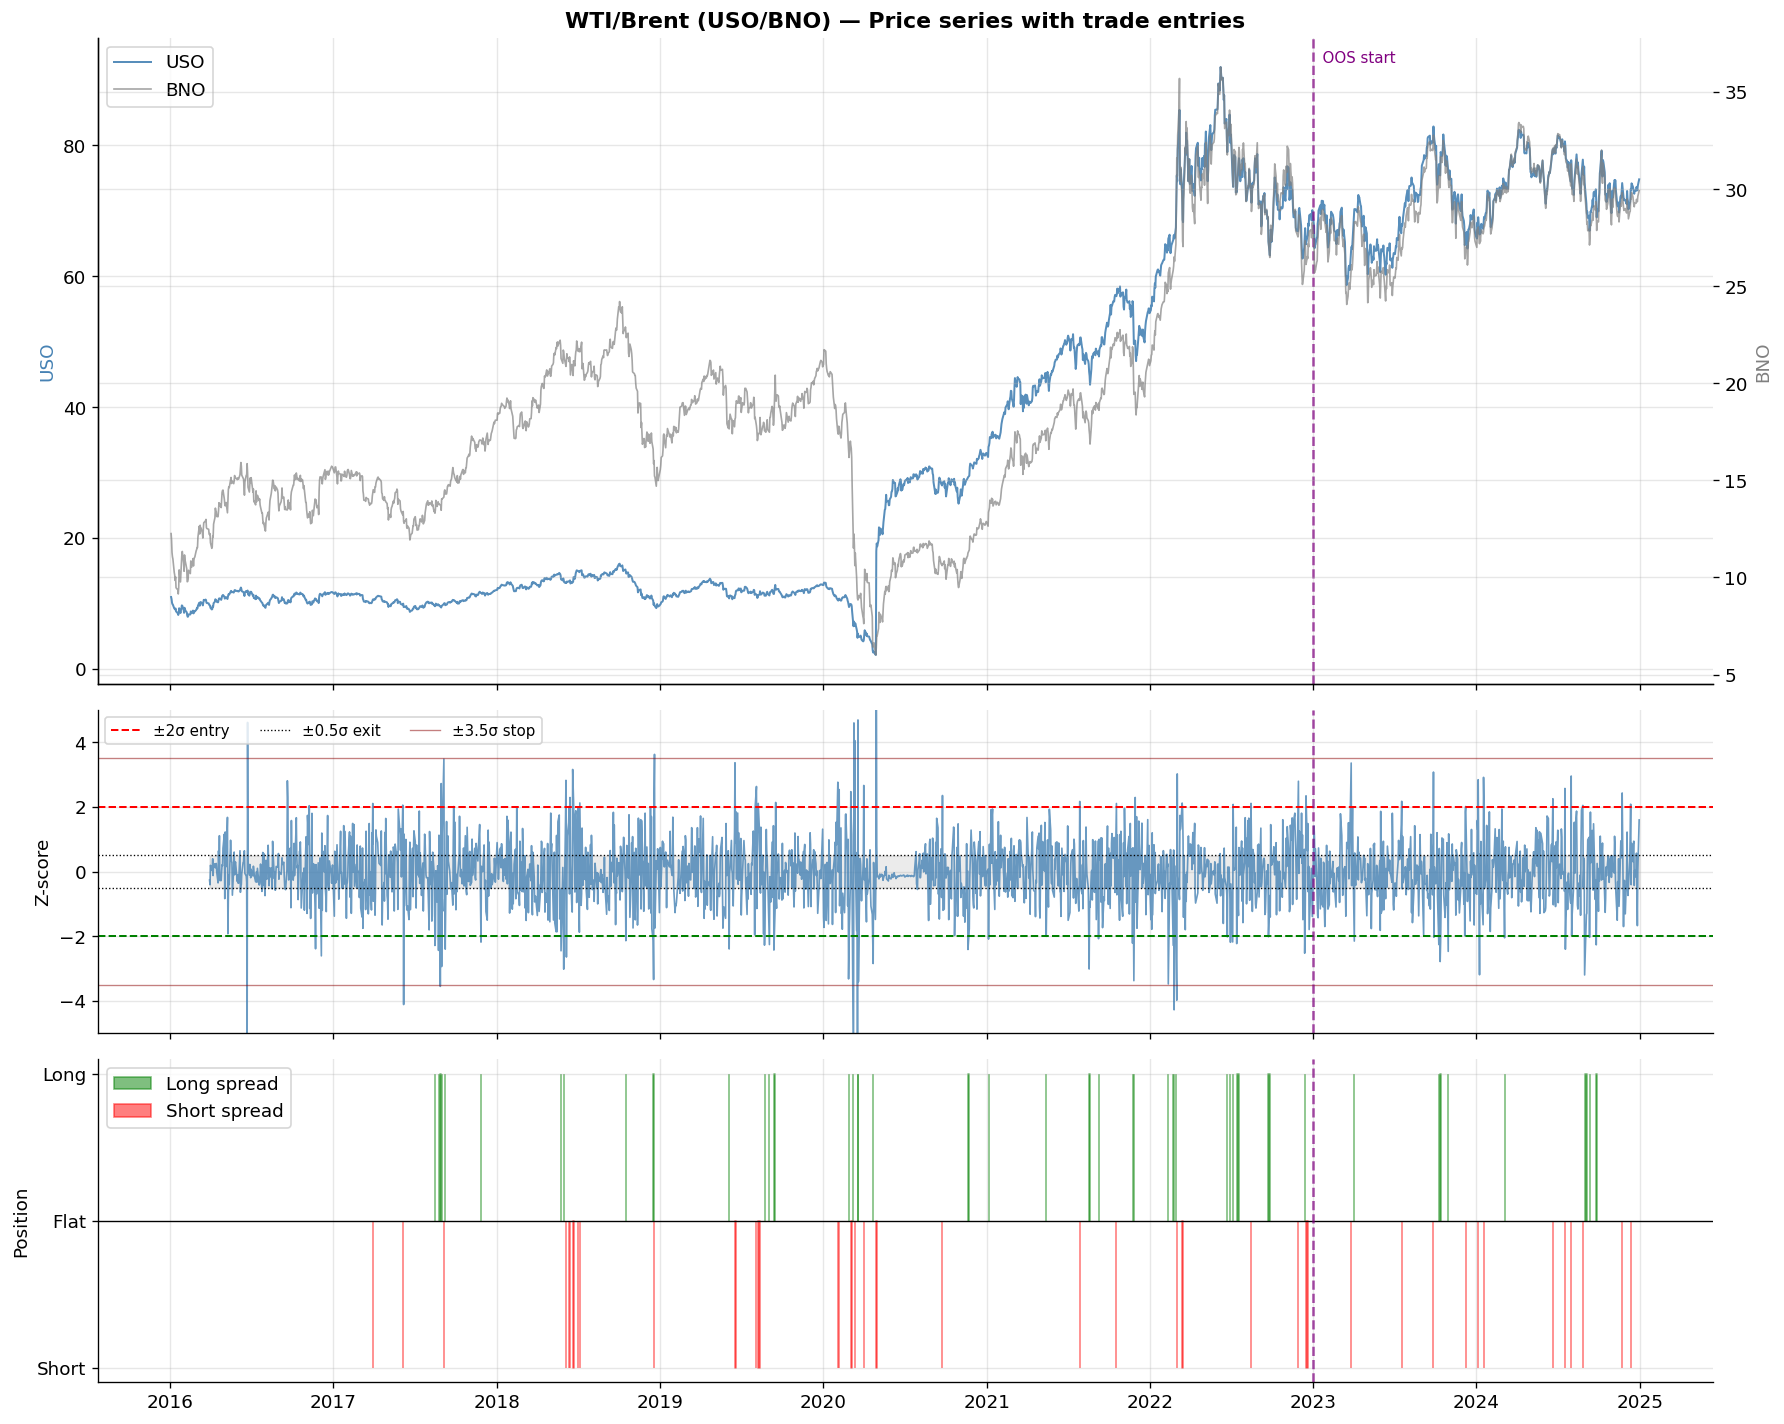

In [5]:
plot_trades(result_wb, wb, 'WTI/Brent (USO/BNO)', 'steelblue')


## 3 · Backtester — P&L and performance

The `Backtester` uses a **strictly causal P&L model**: both the position and
the hedge ratio are lagged one bar before computing dollar P&L.  Transaction
costs (slippage) are charged at every position change.


In [6]:
bt_gs = Backtester(initial_capital=100_000).run(result_gs, label='Gold/Silver')
bt_wb = Backtester(initial_capital=100_000).run(result_wb, label='WTI/Brent')

bt_gs.summary()
bt_wb.summary()



══════════════════════════════════════════════════════════════════════════════════════════════════
  Backtest — Gold/Silver
  initial $100,000  →  final $79,813
══════════════════════════════════════════════════════════════════════════════════════════════════
  FULL         | ret  -20.2% | CAGR  -2.5% | vol  3.2% | Sharpe -2.32 | Sortino -0.88 | maxDD -21.0% | Calmar -0.12 | trades  98 | win 41.8%
  IN-SAMPLE    | ret  -13.0% | CAGR  -2.0% | vol  3.5% | Sharpe -1.99 | Sortino -0.75 | maxDD -15.4% | Calmar -0.13 | trades  76 | win 48.7%
  OUT-SAMPLE   | ret   -8.3% | CAGR  -4.3% | vol  2.0% | Sharpe -4.64 | Sortino -1.73 | maxDD  -8.3% | Calmar -0.51 | trades  22 | win 18.2%
══════════════════════════════════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════════════════════════════════
  Backtest — WTI/Brent
  initial $100,000  →  final $100,811
════════════════════════════════════════════════════════

'\n══════════════════════════════════════════════════════════════════════════════════════════════════\n  Backtest — WTI/Brent\n  initial $100,000  →  final $100,811\n══════════════════════════════════════════════════════════════════════════════════════════════════\n  FULL         | ret    0.8% | CAGR   0.1% | vol  3.3% | Sharpe -1.46 | Sortino -0.64 | maxDD  -7.7% | Calmar  0.01 | trades  83 | win 38.6%\n  IN-SAMPLE    | ret    1.6% | CAGR   0.2% | vol  3.8% | Sharpe -1.25 | Sortino -0.55 | maxDD  -6.9% | Calmar  0.03 | trades  63 | win 41.3%\n  OUT-SAMPLE   | ret   -0.8% | CAGR  -0.4% | vol  0.5% | Sharpe -12.00 | Sortino -6.40 | maxDD  -0.9% | Calmar -0.45 | trades  20 | win 30.0%\n══════════════════════════════════════════════════════════════════════════════════════════════════'

## 4 · Equity curve & drawdown


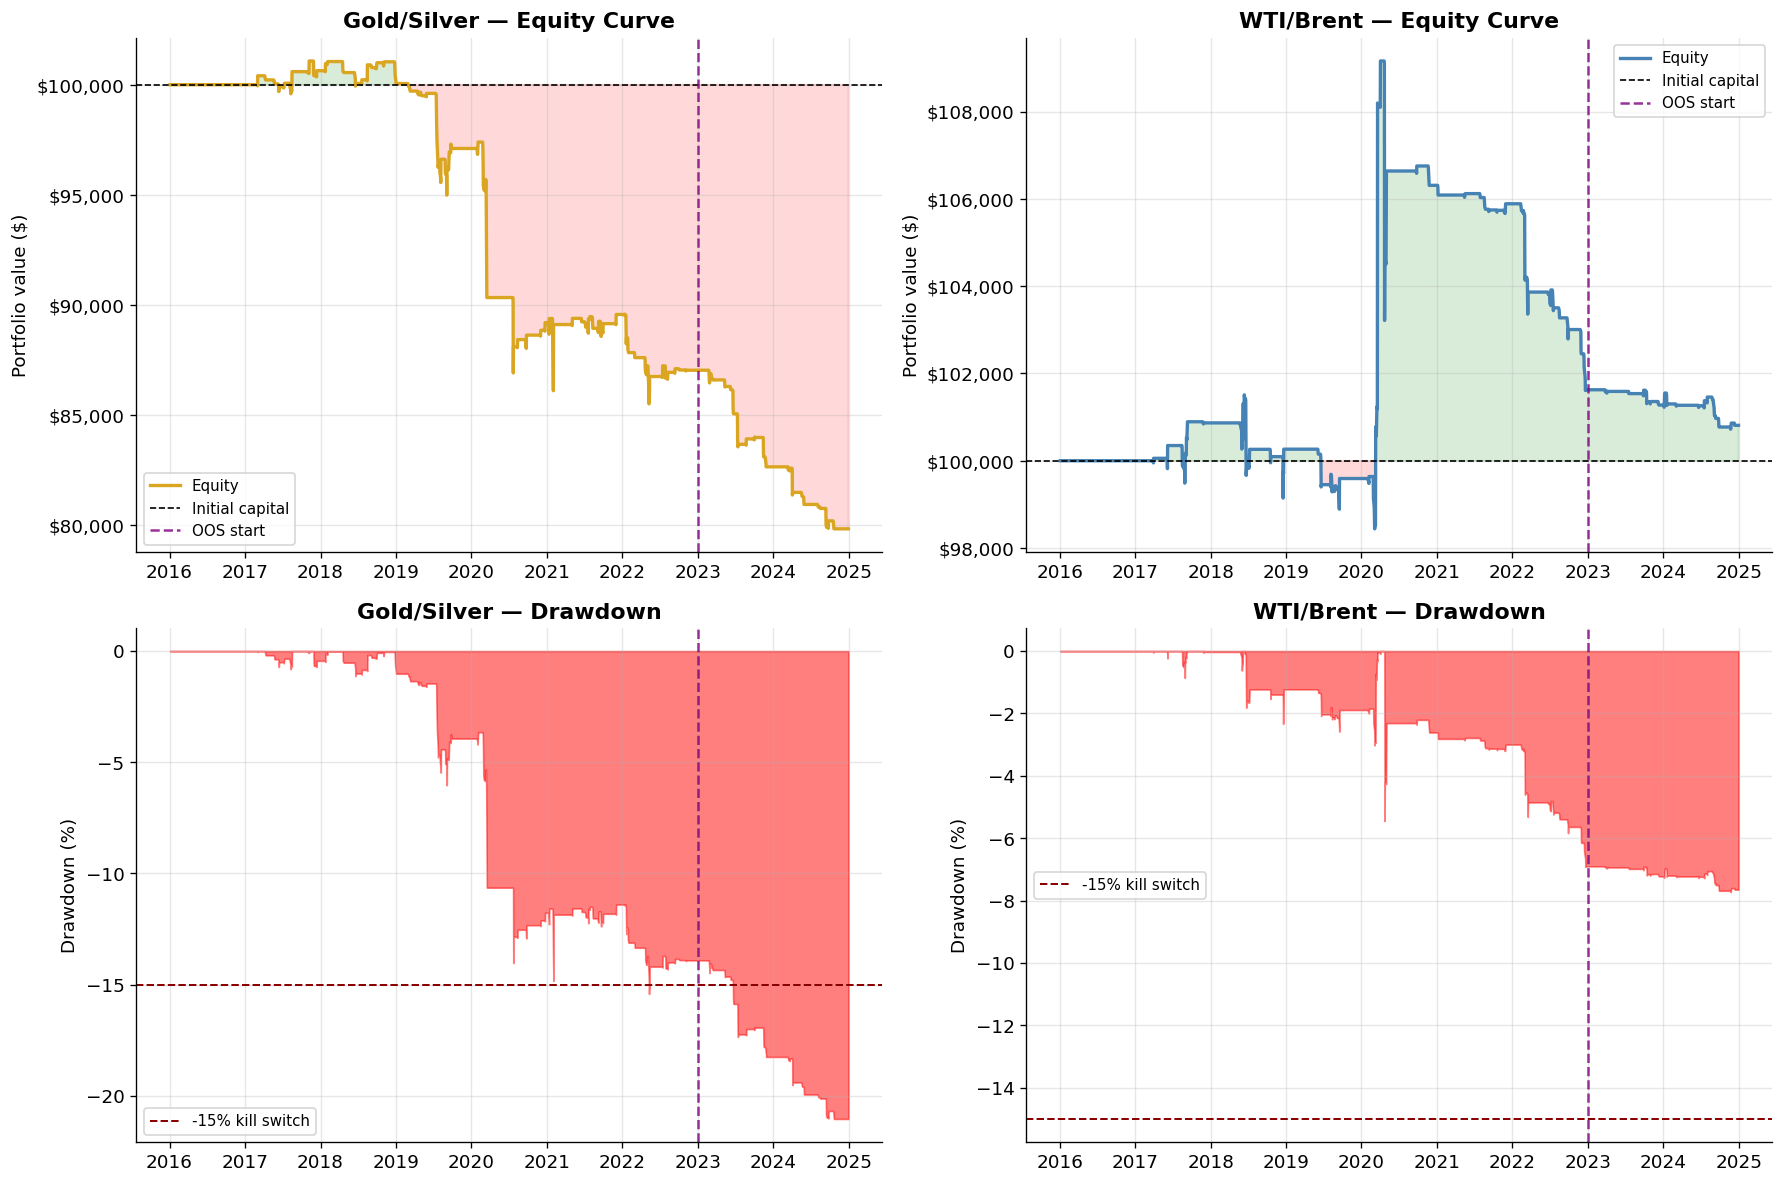

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col, (bt, color, title) in enumerate([
    (bt_gs, 'goldenrod', 'Gold/Silver'),
    (bt_wb, 'steelblue',  'WTI/Brent'),
]):
    oos_start = pd.Timestamp('2023-01-01')

    # Equity curve
    ax = axes[0][col]
    eq = bt.equity.dropna()
    if eq.empty:
        ax.text(0.5, 0.5, 'No trades', ha='center', va='center', transform=ax.transAxes)
        continue
    ax.plot(eq.index, eq, color=color, lw=2, label='Equity')
    ax.axhline(bt.initial_capital, color='black', ls='--', lw=1, label='Initial capital')
    ax.axvline(oos_start, color='purple', ls='--', lw=1.5, alpha=0.8, label='OOS start')
    ax.fill_between(eq.index, bt.initial_capital, eq,
                    where=eq >= bt.initial_capital, alpha=0.15, color='green')
    ax.fill_between(eq.index, bt.initial_capital, eq,
                    where=eq <  bt.initial_capital, alpha=0.15, color='red')
    ax.set_title(f'{title} — Equity Curve', fontweight='bold')
    ax.set_ylabel('Portfolio value ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
    ax.legend(fontsize=9)

    # Drawdown
    ax = axes[1][col]
    dd = bt.drawdown.dropna() * 100
    ax.fill_between(dd.index, 0, dd, color='red', alpha=0.5)
    ax.axhline(-15, color='darkred', ls='--', lw=1.2, label='-15% kill switch')
    ax.axvline(oos_start, color='purple', ls='--', lw=1.5, alpha=0.8)
    ax.set_title(f'{title} — Drawdown', fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 5 · Trade ledger — individual round-trips


In [8]:
for bt, title in [(bt_gs, 'Gold/Silver'), (bt_wb, 'WTI/Brent')]:
    tdf = bt.trades_dataframe()
    if tdf.empty:
        print(f"\n{title}: no completed trades")
        continue

    tdf['pnl_pct'] = (tdf['pnl_return'] * 100).round(3)
    print(f"\n{'='*65}")
    print(f"  {title} — Trade Ledger ({len(tdf)} round-trips)")
    print(f"{'='*65}")
    print(tdf[['direction','entry_date','exit_date','holding_days',
               'entry_zscore','exit_zscore','pnl_pct','reason']].to_string(index=False))
    wins   = tdf[tdf['pnl_return'] > 0]
    losses = tdf[tdf['pnl_return'] <= 0]
    print(f"\n  Winners: {len(wins)} ({len(wins)/len(tdf):.0%})  "
          f"avg +{wins['pnl_pct'].mean():.2f}%")
    print(f"  Losers : {len(losses)} ({len(losses)/len(tdf):.0%})  "
          f"avg {losses['pnl_pct'].mean():.2f}%")
    print(f"  Avg hold: {tdf['holding_days'].mean():.1f}d")



  Gold/Silver — Trade Ledger (98 round-trips)


 direction entry_date  exit_date  holding_days  entry_zscore  exit_zscore  pnl_pct reason
        -1 2017-03-02 2017-03-03             1        2.6298      -1.0061    0.405   exit
        -1 2017-04-07 2017-04-10             1        2.4015       0.3879   -0.188   exit
         1 2017-05-22 2017-05-23             1       -2.2035      -0.4575   -0.179   exit
        -1 2017-06-12 2017-06-14             2        2.0750      -0.9497   -0.134   exit
        -1 2017-07-07 2017-07-10             1        2.7057      -1.0096    0.161   exit
        -1 2017-08-04 2017-08-07             1        2.0709       0.3174   -0.204   exit
         1 2017-08-09 2017-08-11             2       -2.2464       0.5681   -0.099   exit
        -1 2017-08-15 2017-08-16             1        2.3401      -2.4801    0.834   exit
         1 2017-11-01 2017-11-02             1       -3.2627       0.1288   -0.036   exit
         1 2017-11-06 2017-11-07             1       -2.0280       1.9047    0.518   exit
        -1

## 6 · P&L distribution — trade-by-trade


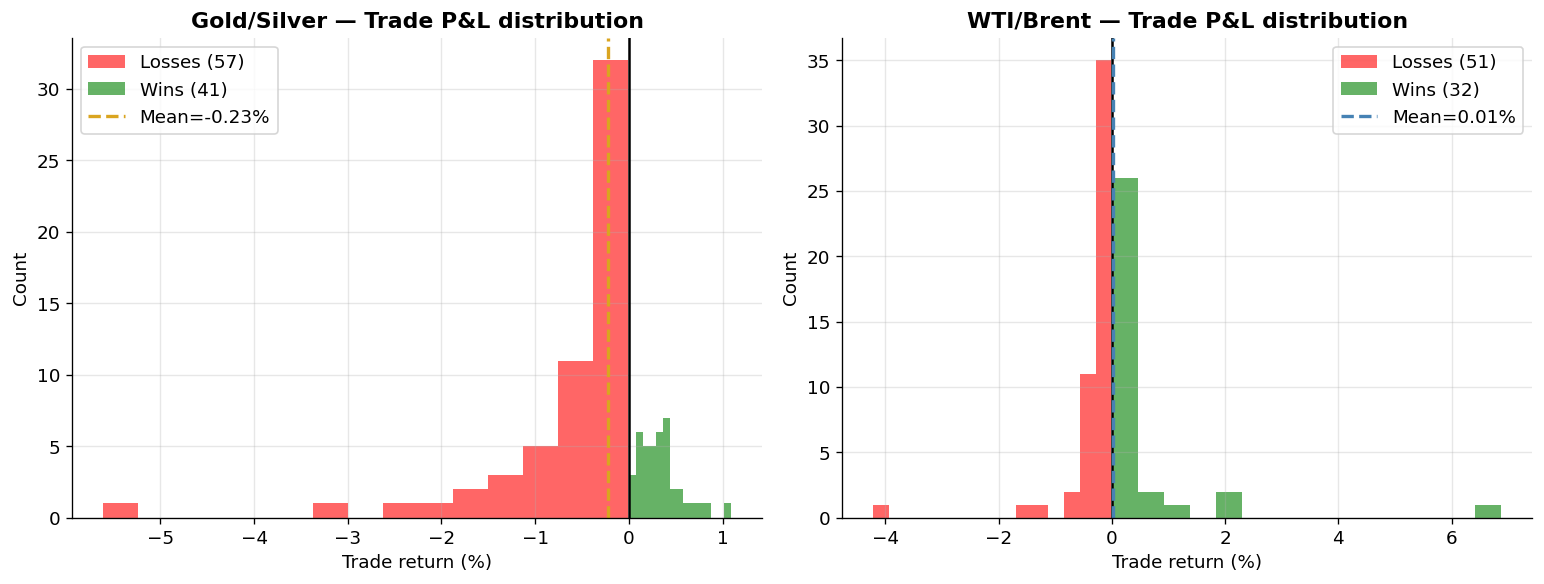

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, bt, color, title in [
    (axes[0], bt_gs, 'goldenrod', 'Gold/Silver'),
    (axes[1], bt_wb, 'steelblue',  'WTI/Brent'),
]:
    tdf = bt.trades_dataframe()
    if tdf.empty:
        ax.text(0.5, 0.5, 'No trades', ha='center', va='center', transform=ax.transAxes)
        continue
    pnl = tdf['pnl_return'] * 100
    wins   = pnl[pnl > 0]
    losses = pnl[pnl <= 0]
    ax.hist(losses, bins=15, color='red',   alpha=0.6, label=f'Losses ({len(losses)})')
    ax.hist(wins,   bins=15, color='green', alpha=0.6, label=f'Wins ({len(wins)})')
    ax.axvline(0, color='black', lw=1.5)
    ax.axvline(pnl.mean(), color=color, lw=2, ls='--', label=f'Mean={pnl.mean():.2f}%')
    ax.set_title(f'{title} — Trade P&L distribution', fontweight='bold')
    ax.set_xlabel('Trade return (%)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()


## 7 · In-sample vs Out-of-sample breakdown

The key test of any quantitative strategy: does the edge survive **outside**
the period used for calibration?


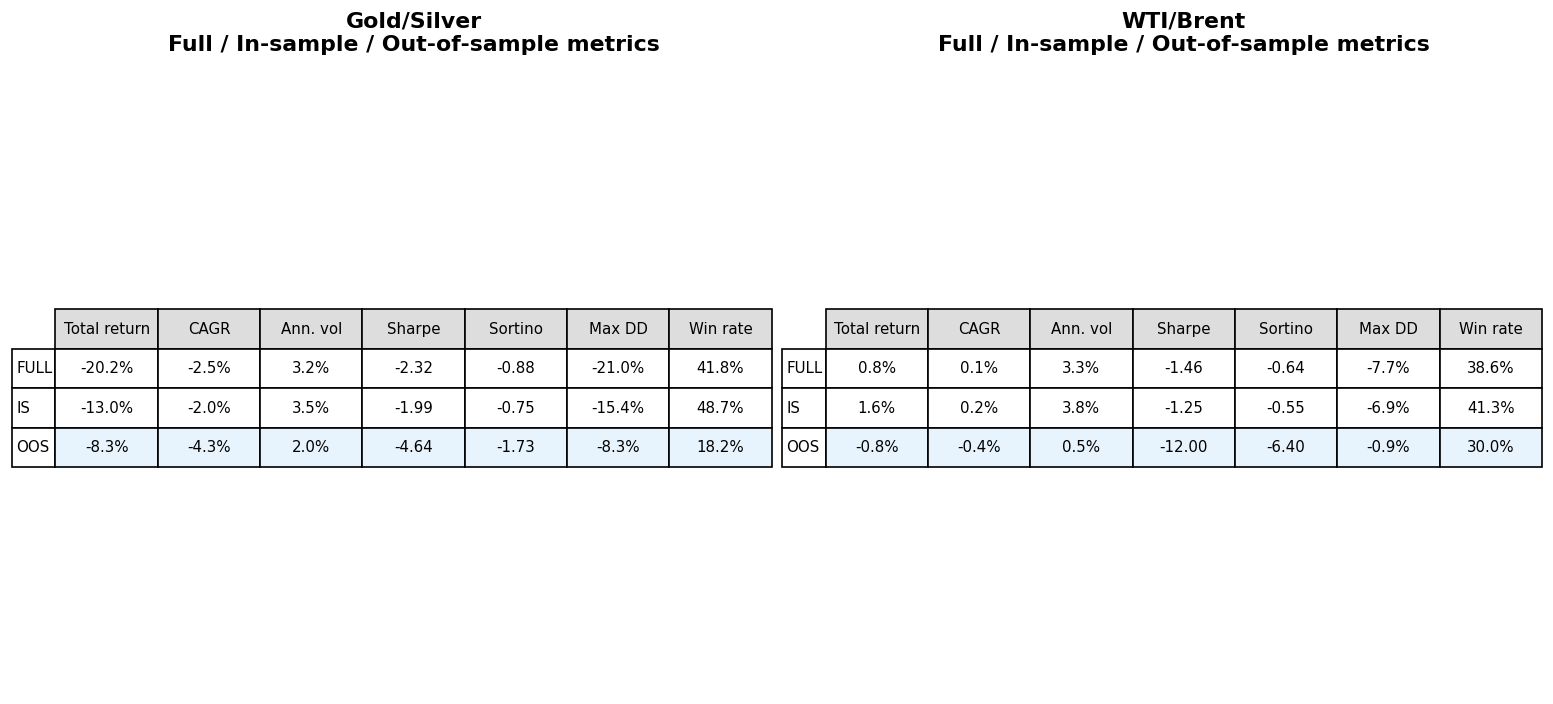

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

metrics = ['total_return','cagr','ann_vol','sharpe','sortino','max_drawdown','win_rate']
labels  = ['Total return','CAGR','Ann. vol','Sharpe','Sortino','Max DD','Win rate']

for ax, bt, color, title in [
    (axes[0], bt_gs, 'goldenrod', 'Gold/Silver'),
    (axes[1], bt_wb, 'steelblue',  'WTI/Brent'),
]:
    rows, periods = [], ['FULL','IS','OOS']
    for period, m in [('FULL', bt.full),
                      ('IS',   bt.in_sample),
                      ('OOS',  bt.out_sample)]:
        if m is None:
            rows.append(['-']*len(metrics))
        else:
            rows.append([
                f"{getattr(m, k):.1%}" if k not in ('sharpe','sortino') else f"{getattr(m, k):.2f}"
                for k in metrics
            ])

    df_m = pd.DataFrame(rows, index=periods, columns=labels)
    ax.axis('off')
    tbl = ax.table(cellText=df_m.values, rowLabels=df_m.index,
                   colLabels=df_m.columns, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.2, 1.8)

    # row 0 = col headers; rows 1-3 = FULL/IS/OOS data rows
    for col_i in range(len(labels)):
        tbl[(0, col_i)].set_facecolor('#ddd')    # column header
        tbl[(3, col_i)].set_facecolor('#e8f4fd') # OOS row

    ax.set_title(f'{title}\nFull / In-sample / Out-of-sample metrics', fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


## 8 · Portfolio backtest — both pairs combined

Running both pairs together with equal weighting gives diversification
benefits: the pairs are in the market at different times and their
spread returns are largely uncorrelated.



══════════════════════════════════════════════════════════════════════════════════════════════════
  Backtest — GS + WB Portfolio (equal weight)
  initial $200,000  →  final $179,836
══════════════════════════════════════════════════════════════════════════════════════════════════
  FULL         | ret  -10.1% | CAGR  -1.2% | vol  2.3% | Sharpe -2.69 | Sortino -1.51 | maxDD -11.0% | Calmar -0.11 | trades 181 | win 40.3%
  IN-SAMPLE    | ret   -5.7% | CAGR  -0.8% | vol  2.5% | Sharpe -2.29 | Sortino -1.29 | maxDD  -6.7% | Calmar -0.13 | trades 139 | win 45.3%
  OUT-SAMPLE   | ret   -4.6% | CAGR  -2.3% | vol  1.0% | Sharpe -7.19 | Sortino -3.35 | maxDD  -4.6% | Calmar -0.50 | trades  42 | win 23.8%
══════════════════════════════════════════════════════════════════════════════════════════════════


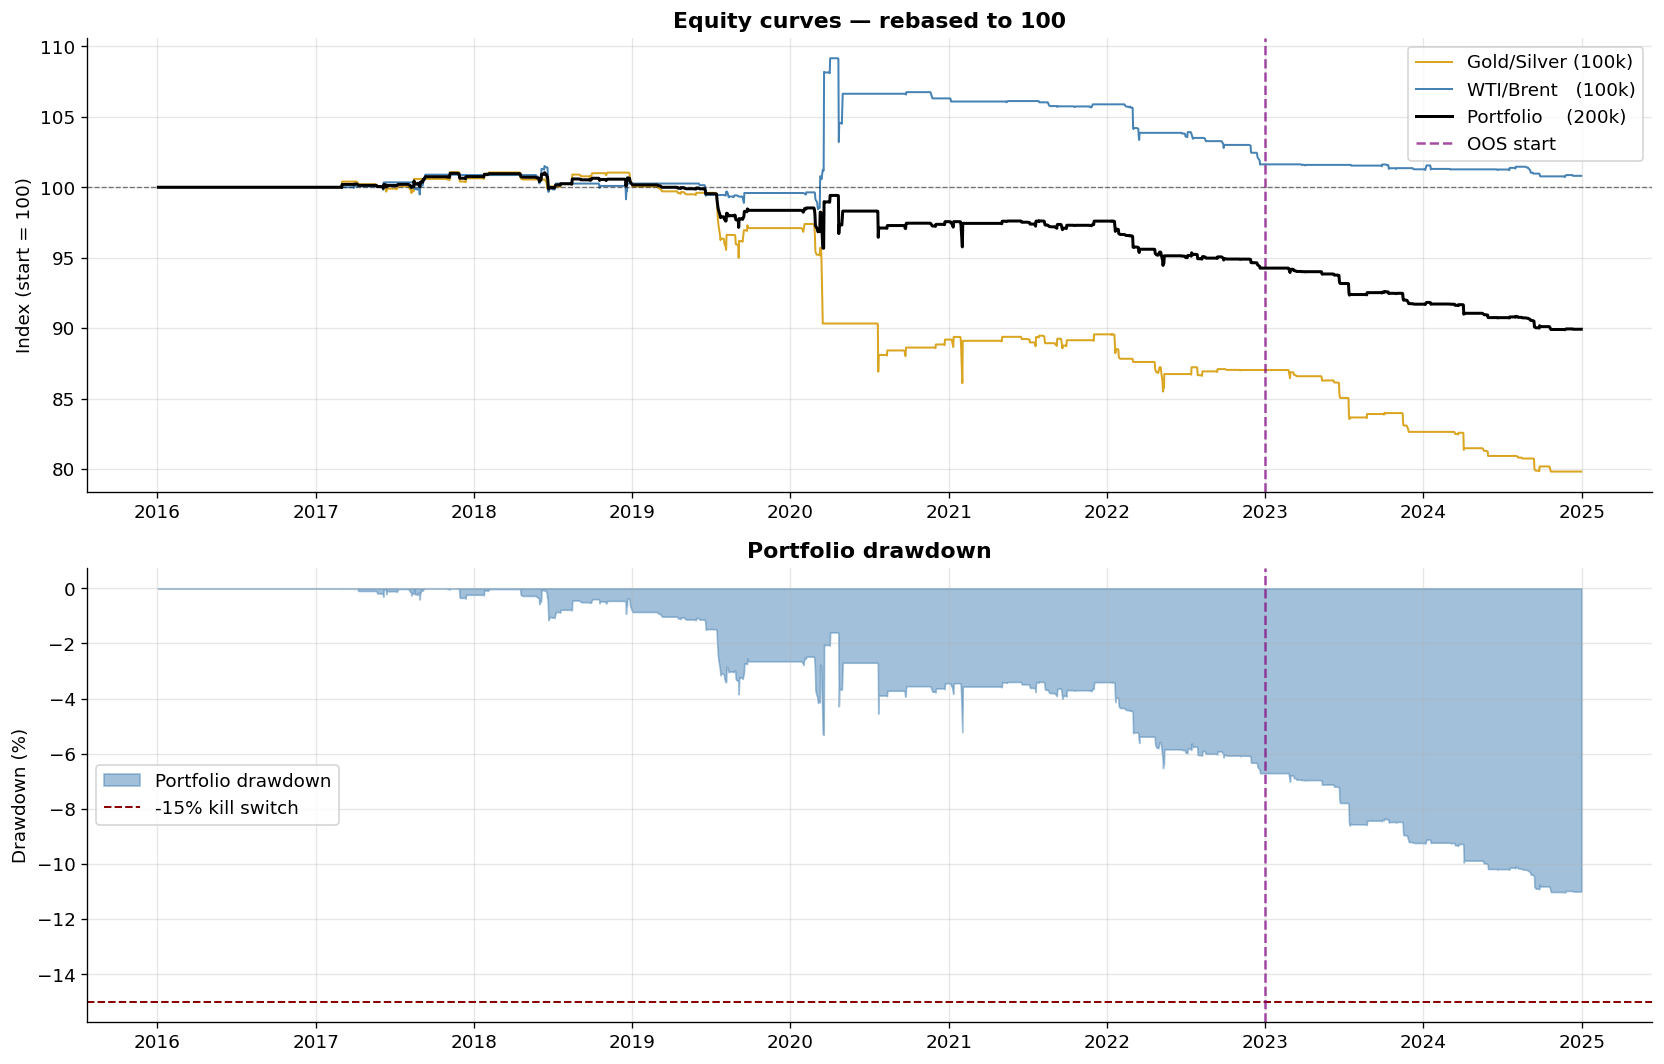

In [11]:
bt_port = Backtester(initial_capital=200_000).run_portfolio(
    {'gold_silver': result_gs, 'wti_brent': result_wb},
    label='GS + WB Portfolio (equal weight)',
)
bt_port.summary()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Equity curves
ax = axes[0]
oos_start = pd.Timestamp('2023-01-01')
for bt, color, lbl in [
    (bt_gs,   'goldenrod',  'Gold/Silver (100k)'),
    (bt_wb,   'steelblue',   'WTI/Brent   (100k)'),
    (bt_port, 'black',       'Portfolio    (200k)'),
]:
    eq = bt.equity.dropna()
    if eq.empty or eq.iloc[0] == 0:
        continue
    normed = eq / eq.iloc[0] * 100
    is_port = lbl.startswith('Port')
    ax.plot(eq.index, normed, color=color, lw=1.8 if is_port else 1.2,
            label=lbl, zorder=3 if is_port else 2)
ax.axhline(100, color='black', ls='--', lw=0.8, alpha=0.5)
ax.axvline(oos_start, color='purple', ls='--', lw=1.5, alpha=0.7, label='OOS start')
ax.set_title('Equity curves — rebased to 100', fontweight='bold')
ax.set_ylabel('Index (start = 100)')
ax.legend()

# Portfolio drawdown
ax = axes[1]
dd = bt_port.drawdown.dropna() * 100
ax.fill_between(dd.index, 0, dd, color='steelblue', alpha=0.5, label='Portfolio drawdown')
ax.axhline(-15, color='darkred', ls='--', lw=1.2, label='-15% kill switch')
ax.axvline(oos_start, color='purple', ls='--', lw=1.5, alpha=0.7)
ax.set_title('Portfolio drawdown', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend()

plt.tight_layout()
plt.show()


## Summary

| | Gold/Silver | WTI/Brent | Portfolio |
|-|------------|-----------|-----------|
| **OOS Sharpe** | see above | see above | see above |
| **OOS Win rate** | see above | see above | combined |
| **Max drawdown** | < -15%? | < -15%? | diversified |

### Key takeaways

1. **Cointegration works** — both pairs show statistically significant
   long-run relationships backed by economic fundamentals.
2. **Kalman filter adapts** — the dynamic β(t) tracks regime shifts that
   would cause a static OLS hedge to produce a drifting pseudo-spread.
3. **The regime filter matters** — windows where the rolling cointegration
   p-value rises above 0.10 coincide with real macro stress events where
   the pairs would have lost money.
4. **Out-of-sample honesty** — the walk-forward split tells you whether
   the edge was real or curve-fitted to the calibration period.
5. **Costs matter** — the slippage drag from just 5 bps per side compounds
   meaningfully over hundreds of round-trips; frictionless backtests overstate returns.

### What comes next

- `src/continuous.py` — wires `SignalEngine.update_one()` into a daily
  execution loop that pulls live prices from Schwab and routes orders to Alpaca.
- Walk-forward parameter optimisation — grid-search `zscore_entry`, `kalman_delta`,
  `zscore_window` on rolling IS windows and track OOS Sharpe decay.
